## BIG DATA Project (Graph) 

Group: 

- Luis Mendes 20221949
-
-
- Veronica Mendes 20221945

## 1. Project Overview & Goals
This project analyzes the US domestic flight network to identify critical hubs, airline performance, and structural patterns using PySpark DataFrames, SparkSQL, and GraphFrames.  

Key Objectives:
- Identify Hub Importance: Use PageRank to find the most influential airports in the network. 
- Network Centrality: Analyze in-degree and out-degree to optimize airport resources.  
- Pattern Discovery: Use Motif Finding to identify specific flight routes like "circular" trips.  
- Efficiency Analysis: Evaluate delays and flight counts using SparkSQL for fast summarization. 

## 2. Imports & Data Loading

In [1]:
#!pip install pyspark
#!pip install spark
#!pip install graphframes
#!pip install scipy

In [19]:
from pyspark.sql import SparkSession

import pandas as pd
import networkx as nx
import scipy
import numpy as np
import matplotlib.pyplot as plt
from graphframes import GraphFrame
from pyspark.sql import functions as F
from matplotlib import cm, colors
from pyspark.sql.functions import col, count, when, avg, round as spark_round 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType


# Initialize Spark
spark = SparkSession.builder \
    .appName("FlightGraphAnalysis") \
    .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.11.0") \
    .getOrCreate()

In [2]:
# Load Data
airports_df = spark.read.csv("flight/airports.csv", header=True, inferSchema=True)
airlines_df = spark.read.csv("flight/airlines.csv", header=True, inferSchema=True)
flights_df = spark.read.csv("flight/flights.csv", header=True, inferSchema=True)

In [3]:
# 1. Join Flights with Airlines and select primary flight info + new airline name
flights_master = flights_df.alias("f").join(
    airlines_df.alias("a"), 
    F.col("f.AIRLINE") == F.col("a.IATA_CODE"), 
    "inner"
).select(
    "f.YEAR", "f.MONTH", "f.DAY", "f.DAY_OF_WEEK", "f.AIRLINE", 
    "f.ORIGIN_AIRPORT", "f.DESTINATION_AIRPORT", "f.SCHEDULED_DEPARTURE", 
    "f.DEPARTURE_DELAY", "f.AIR_TIME", "f.DISTANCE", "f.SCHEDULED_ARRIVAL", 
    "f.ARRIVAL_DELAY", "f.DIVERTED", "f.CANCELLED",
    F.col("a.AIRLINE").alias("AIRLINE_NAME")
)

# 2. Join with Airports for ORIGIN metadata
flights_master = flights_master.alias("master").join(
    airports_df.alias("orig"), 
    F.col("master.ORIGIN_AIRPORT") == F.col("orig.IATA_CODE"), 
    "inner"
).select(
    "master.*", 
    F.col("orig.AIRPORT").alias("ORIGIN_AIRPORT_NAME"),
    F.col("orig.CITY").alias("ORIGIN_CITY"),
    F.col("orig.STATE").alias("ORIGIN_STATE"),
    F.col("orig.LATITUDE").alias("ORIGIN_LAT"),
    F.col("orig.LONGITUDE").alias("ORIGIN_LON")
)

# 3. Join with Airports for DESTINATION metadata
flights_master = flights_master.alias("master").join(
    airports_df.alias("dest"), 
    F.col("master.DESTINATION_AIRPORT") == F.col("dest.IATA_CODE"), 
    "left"
).select(
    "master.*", 
    F.col("dest.AIRPORT").alias("DEST_AIRPORT_NAME"),
    F.col("dest.CITY").alias("DEST_CITY"),
    F.col("dest.STATE").alias("DEST_STATE"),
    F.col("dest.LATITUDE").alias("DEST_LAT"),
    F.col("dest.LONGITUDE").alias("DEST_LON")
)

# Show sample of the cleaned dataframe
flights_master.show(10)

26/05/03 22:30:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----+-----+---+-----------+-------+--------------+-------------------+-------------------+---------------+--------+--------+-----------------+-------------+--------+---------+--------------------+--------------------+-------------+------------+----------+----------+--------------------+-----------------+----------+--------+----------+
|YEAR|MONTH|DAY|DAY_OF_WEEK|AIRLINE|ORIGIN_AIRPORT|DESTINATION_AIRPORT|SCHEDULED_DEPARTURE|DEPARTURE_DELAY|AIR_TIME|DISTANCE|SCHEDULED_ARRIVAL|ARRIVAL_DELAY|DIVERTED|CANCELLED|        AIRLINE_NAME| ORIGIN_AIRPORT_NAME|  ORIGIN_CITY|ORIGIN_STATE|ORIGIN_LAT|ORIGIN_LON|   DEST_AIRPORT_NAME|        DEST_CITY|DEST_STATE|DEST_LAT|  DEST_LON|
+----+-----+---+-----------+-------+--------------+-------------------+-------------------+---------------+--------+--------+-----------------+-------------+--------+---------+--------------------+--------------------+-------------+------------+----------+----------+--------------------+-----------------+----------+-------

## 3. Explanatory Data Analysis (EDA)

In [4]:
nrows = flights_master.count()
columns = flights_master.columns

print(f"Total Records: {nrows:,}")
print(f"Total Features: {columns.__len__()}")

Total Records: 5,332,914
Total Features: 26


In [5]:
flights_master.printSchema()

root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_DELAY: integer (nullable = true)
 |-- DIVERTED: integer (nullable = true)
 |-- CANCELLED: integer (nullable = true)
 |-- AIRLINE_NAME: string (nullable = true)
 |-- ORIGIN_AIRPORT_NAME: string (nullable = true)
 |-- ORIGIN_CITY: string (nullable = true)
 |-- ORIGIN_STATE: string (nullable = true)
 |-- ORIGIN_LAT: double (nullable = true)
 |-- ORIGIN_LON: double (nullable = true)
 |-- DEST_AIRPORT_NAME: string (nullable = true)
 |-- DEST_CITY: string (null

In [6]:
# Calculate values (Counts and Percentages)
# We use spark_round to avoid potential Python precision errors
stats = flights_master.select([
    count(when(col(c).isNull(), c)).alias(f"{c}_count") for c in columns
] + [
    spark_round((count(when(col(c).isNull(), c)) / nrows) * 100, 2).alias(f"{c}_percent") 
    for c in columns
])

# Extract results to format them vertically
res_dict = stats.first().asDict()

rows_list = []
for c in columns:
    rows_list.append((c, res_dict[f"{c}_count"], f"{res_dict[f'{c}_percent']}%"))

# Create a new DataFrame to display the full summary
summary_df = spark.createDataFrame(rows_list, ["Column", "Total Missing", "Percentage (%)"])

# SHOW ALL: We use n=len(columns) 
summary_df.show(n=len(columns), truncate=False)

+-------------------+-------------+--------------+
|Column             |Total Missing|Percentage (%)|
+-------------------+-------------+--------------+
|YEAR               |0            |0.0%          |
|MONTH              |0            |0.0%          |
|DAY                |0            |0.0%          |
|DAY_OF_WEEK        |0            |0.0%          |
|AIRLINE            |0            |0.0%          |
|ORIGIN_AIRPORT     |0            |0.0%          |
|DESTINATION_AIRPORT|0            |0.0%          |
|SCHEDULED_DEPARTURE|0            |0.0%          |
|DEPARTURE_DELAY    |83814        |1.57%         |
|AIR_TIME           |101784       |1.91%         |
|DISTANCE           |0            |0.0%          |
|SCHEDULED_ARRIVAL  |0            |0.0%          |
|ARRIVAL_DELAY      |101784       |1.91%         |
|DIVERTED           |0            |0.0%          |
|CANCELLED          |0            |0.0%          |
|AIRLINE_NAME       |0            |0.0%          |
|ORIGIN_AIRPORT_NAME|0         

In [7]:
# 1. Fill missing values in DEPARTURE_DELAY and ARRIVAL_DELAY with 0
flights_master = flights_master.fillna(0, subset=["DEPARTURE_DELAY", "ARRIVAL_DELAY"])

# 2. Delete rows that are missing values in the remaining critical columns
# AIR_TIME, ORIGIN_LAT, ORIGIN_LON, DEST_LAT, and DEST_LON
flights_master = flights_master.dropna(subset=["AIR_TIME", "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON"])

# 3. Delete the variables DIVERTED and CANCELLED
flights_master = flights_master.drop("DIVERTED", "CANCELLED")

# 4. Verify missing values and check that columns were dropped
print("Missing values after cleaning:")
flights_master.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "AIR_TIME", "ORIGIN_LAT", "DEST_LAT"]
]).show()

print("Remaining columns in DataFrame:")
print(flights_master.columns)

Missing values after cleaning:


+---------------+-------------+--------+----------+--------+
|DEPARTURE_DELAY|ARRIVAL_DELAY|AIR_TIME|ORIGIN_LAT|DEST_LAT|
+---------------+-------------+--------+----------+--------+
|              0|            0|       0|         0|       0|
+---------------+-------------+--------+----------+--------+

Remaining columns in DataFrame:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY', 'AIR_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'AIRLINE_NAME', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_AIRPORT_NAME', 'DEST_CITY', 'DEST_STATE', 'DEST_LAT', 'DEST_LON']


In [8]:
nrows = flights_master.count()
columns = flights_master.columns
# Calculate values (Counts and Percentages)
# We use spark_round to avoid potential Python precision errors
stats = flights_master.select([
    count(when(col(c).isNull(), c)).alias(f"{c}_count") for c in columns
] + [
    spark_round((count(when(col(c).isNull(), c)) / nrows) * 100, 2).alias(f"{c}_percent") 
    for c in columns
])

# Extract results to format them vertically
res_dict = stats.first().asDict()

rows_list = []
for c in columns:
    rows_list.append((c, res_dict[f"{c}_count"], f"{res_dict[f'{c}_percent']}%"))

# Create a new DataFrame to display the full summary
summary_df = spark.createDataFrame(rows_list, ["Column", "Total Missing", "Percentage (%)"])

# SHOW ALL: We use n=len(columns) 
summary_df.show(n=len(columns), truncate=False)

+-------------------+-------------+--------------+
|Column             |Total Missing|Percentage (%)|
+-------------------+-------------+--------------+
|YEAR               |0            |0.0%          |
|MONTH              |0            |0.0%          |
|DAY                |0            |0.0%          |
|DAY_OF_WEEK        |0            |0.0%          |
|AIRLINE            |0            |0.0%          |
|ORIGIN_AIRPORT     |0            |0.0%          |
|DESTINATION_AIRPORT|0            |0.0%          |
|SCHEDULED_DEPARTURE|0            |0.0%          |
|DEPARTURE_DELAY    |0            |0.0%          |
|AIR_TIME           |0            |0.0%          |
|DISTANCE           |0            |0.0%          |
|SCHEDULED_ARRIVAL  |0            |0.0%          |
|ARRIVAL_DELAY      |0            |0.0%          |
|AIRLINE_NAME       |0            |0.0%          |
|ORIGIN_AIRPORT_NAME|0            |0.0%          |
|ORIGIN_CITY        |0            |0.0%          |
|ORIGIN_STATE       |0         

In [9]:
# List of numerical variables based on your dataset structure
numerical_vars = [
    "DEPARTURE_DELAY", "ARRIVAL_DELAY", "AIR_TIME", "DISTANCE",
    "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON",
    "SCHEDULED_DEPARTURE", "SCHEDULED_ARRIVAL", "YEAR", "MONTH", "DAY"
]

# Display count, mean, stddev, min, max, and quartiles for these variables
flights_master.select(numerical_vars).summary().show()

+-------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-----------------+------------------+-------------------+------------------+-------+------------------+------------------+
|summary|  DEPARTURE_DELAY|    ARRIVAL_DELAY|          AIR_TIME|         DISTANCE|        ORIGIN_LAT|        ORIGIN_LON|         DEST_LAT|          DEST_LON|SCHEDULED_DEPARTURE| SCHEDULED_ARRIVAL|   YEAR|             MONTH|               DAY|
+-------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-----------------+------------------+-------------------+------------------+-------+------------------+------------------+
|  count|          5222000|          5222000|           5222000|          5222000|           5222000|           5222000|          5222000|           5222000|            5222000|           5222000|5222000|           5222000|           5222000|
|   mean|9.700098621217924|4

In [10]:
# Define the categorical columns to analyze
# Fixed syntax: added missing quote for "MONTH"
categorical_cols = [
    "AIRLINE", "AIRLINE_NAME", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", 
    "ORIGIN_AIRPORT_NAME", "DEST_AIRPORT_NAME", "ORIGIN_CITY", "DEST_CITY", 
    "ORIGIN_STATE", "DEST_STATE","DAY_OF_WEEK", 
]

# 1. Calculate Count and Unique Values for all columns
agg_exprs = []
for c in categorical_cols:
    agg_exprs.append(F.count(c).alias(f"{c}_count"))
    agg_exprs.append(F.count_distinct(c).alias(f"{c}_unique"))

# Execute aggregation and convert to dictionary for easy access
# We use .first() to retrieve the results of the global count/unique aggregation
stats_dict = flights_master.select(agg_exprs).first().asDict()

# 2. Calculate Mode for each column individually
table_rows = []
for c in categorical_cols:
    # Mode: Group by the value, count occurrences, and take the top result
    mode_val = flights_master.groupBy(c).count().orderBy(F.col("count").desc()).first()[0]
    
    table_rows.append((
        c, 
        stats_dict[f"{c}_count"], 
        stats_dict[f"{c}_unique"], 
        str(mode_val)
    ))

# 3. Create a new PySpark DataFrame to display the formatted results
cat_summary_table = spark.createDataFrame(table_rows, ["Variable", "Count", "Unique Values", "Mode"])

# 4. Display the results
cat_summary_table.show(truncate=False)

+-------------------+-------+-------------+------------------------------------------------+
|Variable           |Count  |Unique Values|Mode                                            |
+-------------------+-------+-------------+------------------------------------------------+
|AIRLINE            |5222000|14           |WN                                              |
|AIRLINE_NAME       |5222000|14           |Southwest Airlines Co.                          |
|ORIGIN_AIRPORT     |5222000|319          |ATL                                             |
|DESTINATION_AIRPORT|5222000|319          |ATL                                             |
|ORIGIN_AIRPORT_NAME|5222000|319          |Hartsfield-Jackson Atlanta International Airport|
|DEST_AIRPORT_NAME  |5222000|319          |Hartsfield-Jackson Atlanta International Airport|
|ORIGIN_CITY        |5222000|305          |Chicago                                         |
|DEST_CITY          |5222000|305          |Chicago                    

In [11]:
# Convert the airports DataFrame to Pandas
pdf_airports = airports_df.toPandas()

# Create the geographic scatter plot
fig = px.scatter_geo(
    pdf_airports, 
    lat='LATITUDE', 
    lon='LONGITUDE', 
    hover_name='AIRPORT',
    hover_data=['IATA_CODE', 'CITY', 'STATE'], 
    title='US Airport Locations', 
    scope='world'
)

# Customize the colors of the map elements
fig.update_geos(
    showocean=True, oceancolor="LightBlue",  # The ocean blue you requested
    showland=True, landcolor="Ivory",        # The land color (e.g., Ivory, LightGreen, etc)
    showlakes=False,
    showcountries=True, countrycolor="Black"
)

fig.show()

In [17]:
# 1. Aggregate flights_master to get one row per airport
# We group by the origin airport and its metadata to count total departures
airport_stats = flights_master.groupBy(
    "ORIGIN_AIRPORT", 
    "ORIGIN_AIRPORT_NAME", 
    "ORIGIN_CITY", 
    "ORIGIN_STATE", 
    "ORIGIN_LAT", 
    "ORIGIN_LON"
).agg(
    F.count("*").alias("TOTAL_DEPARTURES"),
    F.avg("DEPARTURE_DELAY").alias("AVG_DEP_DELAY"),
    F.avg("ARRIVAL_DELAY").alias("AVG_ARI_DELAY")
)

# 2. Convert to Pandas for Plotly
pdf_flight_map = airport_stats.toPandas()

# 3. Create the geographic scatter plot
fig = px.scatter_geo(
    pdf_flight_map, 
    lat='ORIGIN_LAT', 
    lon='ORIGIN_LON', 
    size='TOTAL_DEPARTURES',      # Circle size based on flight volume
    color='AVG_DEP_DELAY',            # Circle color based on average delay
    hover_name='ORIGIN_AIRPORT_NAME',
    hover_data={
        'ORIGIN_AIRPORT': True, 
        'ORIGIN_CITY': True, 
        'ORIGIN_STATE': True, 
        'TOTAL_DEPARTURES': True, 
        'AVG_ARI_DELAY': True,
        'ORIGIN_LAT': False, # Ensure coordinates don't show in hover if not needed
        'ORIGIN_LON': False
    },
    title='2015 US Flight Traffic & Delays by Hub', 
    scope='world',
    template='plotly_dark',
    color_continuous_scale=px.colors.sequential.Reds,
    # Use labels to change how the column names appear in the hover box
    labels={
        "ORIGIN_AIRPORT": "Airport",
        "ORIGIN_CITY": "City",
        "ORIGIN_STATE": "State",
        "TOTAL_DEPARTURES": "Total Departures",
        "AVG_ARI_DELAY": "Avg Arrival Delay",
        "AVG_DEP_DELAY": "Avg Departure Delay"
    }
)

fig.show()

Number of Flights per Airline 

In [37]:
# 1. Convert the DataFrame column to an RDD
# We only need the AIRLINE_NAME for this calculation
airline_rdd = flights_master.select("AIRLINE_NAME").rdd

# 2. Map Phase:
# Transform each airline name into a key-value pair: (AIRLINE_NAME, 1)
map_phase = airline_rdd.map(lambda row: (row[0], 1))

# 3. Reduce Phase:
# Use reduceByKey to sum the '1's for each unique airline name
reduce_phase = map_phase.reduceByKey(lambda a, b: a + b)

# 4. Sort and Display:
# Sort by the count (index 1 of the tuple) in descending order
flights_per_airline_mr = reduce_phase.sortBy(lambda x: x[1], ascending=False)

# Convert back to a DataFrame to use .show() for a clean table format
result_df = flights_per_airline_mr.toDF(["AIRLINE_NAME", "total_flights"])

result_df.show(14, truncate=False)

+----------------------------+-------------+
|AIRLINE_NAME                |total_flights|
+----------------------------+-------------+
|Southwest Airlines Co.      |1135152      |
|Delta Air Lines Inc.        |791067       |
|American Airlines Inc.      |636554       |
|Skywest Airlines Inc.       |528328       |
|Atlantic Southeast Airlines |508288       |
|United Air Lines Inc.       |462086       |
|American Eagle Airlines Inc.|257130       |
|JetBlue Airways             |240304       |
|US Airways Inc.             |194223       |
|Alaska Airlines Inc.        |157025       |
|Spirit Air Lines            |104500       |
|Frontier Airlines Inc.      |81715        |
|Hawaiian Airlines Inc.      |69815        |
|Virgin America              |55813        |
+----------------------------+-------------+



Average Distance per Flight 

In [38]:
# 1. Convert to RDD and Map phase
# Mapper: (Airline_Name, (Distance, 1))
# We include '1' to keep track of the count for the average calculation
flights_rdd = flights_master.select("AIRLINE_NAME", "DISTANCE").rdd

mapped_rdd = flights_rdd.map(lambda row: (row[0], (row[1], 1)))

# 2. Reduce phase
# Reducer: Sum the distances and sum the counts for each airline key
reduced_rdd = mapped_rdd.reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))

# 3. Final Transformation (Calculate Average)
# Divide total distance by total count
avg_dist_rdd = reduced_rdd.mapValues(lambda total: total[0] / total[1])

# 4. Convert back to DataFrame for clean display
avg_dist_per_airline = avg_dist_rdd.toDF(["Airline", "Avg_Distance"])
avg_dist_per_airline.orderBy("Avg_Distance", ascending=False).show()

+--------------------+------------------+
|             Airline|      Avg_Distance|
+--------------------+------------------+
|      Virgin America|1406.6823679071183|
|United Air Lines ...| 1275.340460433772|
|Alaska Airlines Inc.|1198.3431491800668|
|     JetBlue Airways|  1064.58185048938|
|American Airlines...| 1048.015283856515|
|    Spirit Air Lines| 983.6267655502393|
|Frontier Airlines...| 968.0805971975769|
|     US Airways Inc.| 915.3802587747074|
|Delta Air Lines Inc.| 858.1225433496784|
|Southwest Airline...| 743.1215819555442|
|Hawaiian Airlines...| 632.3657953161928|
|Skywest Airlines ...|497.33097242622006|
|Atlantic Southeas...|462.35091916393856|
|American Eagle Ai...|424.55878738381364|
+--------------------+------------------+



Average Time per Flight 

In [39]:
# 1. Define the UDF for custom logic (Minutes to Hours)
@F.udf(returnType=DoubleType())
def minutes_to_hours(minutes):
    return float(minutes / 60.0) if minutes else 0.0

# 2. Apply UDF, Group by Airline, and Aggregate
avg_time_per_airline = flights_master \
    .withColumn("AIR_TIME_HOURS", minutes_to_hours(F.col("AIR_TIME"))) \
    .groupBy("AIRLINE_NAME") \
    .agg(F.avg("AIR_TIME_HOURS").alias("avg_air_time_hours")) \
    .orderBy(F.col("avg_air_time_hours").desc())

# 3. Show the results
avg_time_per_airline.show(truncate=False)

+----------------------------+------------------+
|AIRLINE_NAME                |avg_air_time_hours|
+----------------------------+------------------+
|Virgin America              |3.05013079390107  |
|United Air Lines Inc.       |2.7560920838689307|
|Alaska Airlines Inc.        |2.630878628668456 |
|JetBlue Airways             |2.4023657533790446|
|American Airlines Inc.      |2.342643672021597 |
|Spirit Air Lines            |2.2036293460925003|
|Frontier Airlines Inc.      |2.174018030145425 |
|US Airways Inc.             |2.0962372290271025|
|Delta Air Lines Inc.        |1.9378949149271933|
|Southwest Airlines Co.      |1.7223093618005607|
|Hawaiian Airlines Inc.      |1.4160478884671206|
|Skywest Airlines Inc.       |1.2610463891118084|
|Atlantic Southeast Airlines |1.2147474135398204|
|American Eagle Airlines Inc.|1.1208752382063485|
+----------------------------+------------------+



Top 3 Arriving Airlines per Airport 

In [42]:
# 1. Ensure the DataFrame is registered as a temp view
flights_master.createOrReplaceTempView("flights_table")

# 2. Execute SQL with Window Function
top_3_sql = spark.sql("""
    WITH AirlineCounts AS (
        SELECT 
            DESTINATION_AIRPORT, 
            AIRLINE_NAME, 
            COUNT(*) as flight_count
        FROM flights_table
        GROUP BY DESTINATION_AIRPORT, AIRLINE_NAME
    ),
    RankedAirlines AS (
        SELECT 
            DESTINATION_AIRPORT, 
            AIRLINE_NAME, 
            flight_count,
            ROW_NUMBER() OVER (
                PARTITION BY DESTINATION_AIRPORT 
                ORDER BY flight_count DESC
            ) as rank
        FROM AirlineCounts
    )
    SELECT * 
    FROM RankedAirlines 
    WHERE rank <= 3
    ORDER BY DESTINATION_AIRPORT, rank
""")

# 3. Display results
top_3_sql.show(20, truncate=False)

+-------------------+----------------------------+------------+----+
|DESTINATION_AIRPORT|AIRLINE_NAME                |flight_count|rank|
+-------------------+----------------------------+------------+----+
|ABE                |Atlantic Southeast Airlines |1862        |1   |
|ABE                |Delta Air Lines Inc.        |307         |2   |
|ABE                |Skywest Airlines Inc.       |51          |3   |
|ABI                |American Eagle Airlines Inc.|2224        |1   |
|ABQ                |Southwest Airlines Co.      |10780       |1   |
|ABQ                |Skywest Airlines Inc.       |3258        |2   |
|ABQ                |American Airlines Inc.      |1821        |3   |
|ABR                |Skywest Airlines Inc.       |657         |1   |
|ABY                |Atlantic Southeast Airlines |864         |1   |
|ACK                |JetBlue Airways             |487         |1   |
|ACT                |Atlantic Southeast Airlines |1020        |1   |
|ACT                |American Eagl

## 4) GRAPH

In [ ]:
âdd all the necesary information on the edges (distance, time, ect)

Filter only airports that have at least 10000 flights on a year (that is 2 flights per hour on half a day in a year)

plot the airports, connections (simpler as it is on the geomap)
Do pagerank, centrality, in outher connections and other things based on the especific "metric"

-metrics are: number of flights, distance, airtime

In [22]:
# Define Vertices (Airports)
v = airports_df.select("IATA_CODE").withColumnRenamed("IATA_CODE", "id").distinct()

# Define Edges (Flights)
# We use ORIGIN and DESTINATION to create the directed relationship
e = flights_df.select("ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE") \
    .withColumnRenamed("ORIGIN_AIRPORT", "src") \
    .withColumnRenamed("DESTINATION_AIRPORT", "dst")

# Create the GraphFrame
g = GraphFrame(v, e)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/sql/classic/dataframe.py:146: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


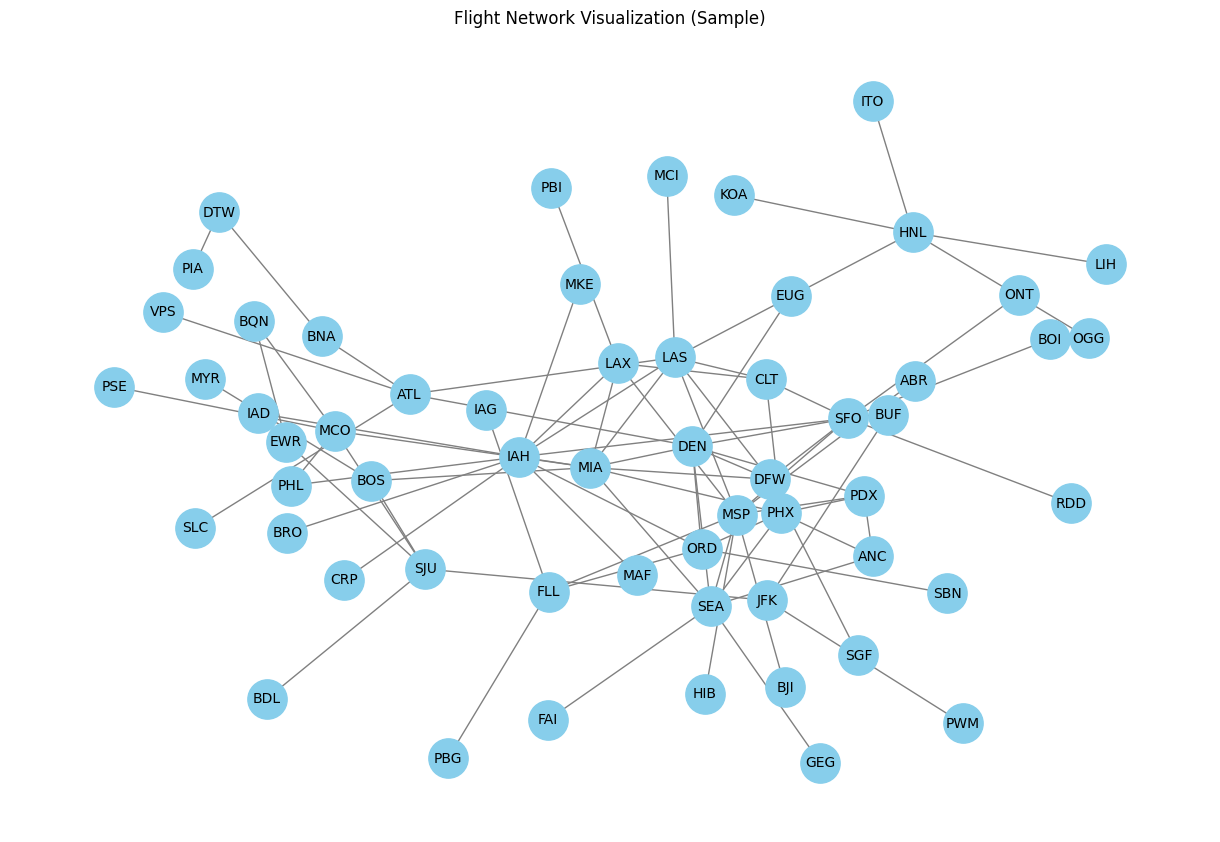

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Sample the edges (don't visualize 100k+ flights at once!)
# Let's take 100 flights to see a clean network
sub_e = g.edges.limit(100).toPandas()

# 2. Create a NetworkX Graph
G = nx.from_pandas_edgelist(sub_e, source='src', target='dst', edge_attr=True)

# 3. Plot
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5) # k controls the distance between nodes
nx.draw(G, pos, with_labels=True, node_color='skyblue', 
        node_size=800, edge_color='gray', linewidths=1, font_size=10)

plt.title("Flight Network Visualization (Sample)")
plt.show()

In [25]:
pageRanks = g.pageRank(
    resetProbability=0.15, tol=0.01
)

pageRanks.show(10)

26/05/03 20:03:59 ERROR Executor: Exception in task 1.0 in stage 233.0 (TID 1141)
java.lang.OutOfMemoryError: Java heap space
	at java.base/java.lang.reflect.Array.newInstance(Array.java:78)
	at scala.reflect.ClassTag$GenericClassTag.newArray(ClassTag.scala:149)
	at org.apache.spark.util.collection.PrimitiveVector.copyArrayWithLength(PrimitiveVector.scala:87)
	at org.apache.spark.util.collection.PrimitiveVector.resize(PrimitiveVector.scala:74)
	at org.apache.spark.util.collection.PrimitiveVector.$plus$eq(PrimitiveVector.scala:41)
	at org.apache.spark.graphframes.graphx.impl.EdgePartitionBuilder.add(EdgePartitionBuilder.scala:36)
	at org.apache.spark.graphframes.graphx.EdgeRDD$.$anonfun$fromEdges$2(EdgeRDD.scala:115)
	at org.apache.spark.graphframes.graphx.EdgeRDD$.$anonfun$fromEdges$2$adapted(EdgeRDD.scala:114)
	at org.apache.spark.graphframes.graphx.EdgeRDD$$$Lambda$5595/0x000075dd155371d8.apply(Unknown Source)
	at scala.collection.IterableOnceOps.foreach(IterableOnce.scala:630)
	at s

ConnectionRefusedError: [Errno 111] Connection refused

In [26]:
# Run PageRank
# 'resetProbability' is the probability of jumping to a random node (alpha)
# 'maxIter' is the number of times the algorithm propagates the influence
results = g.pageRank(resetProbability=0.15, maxIter=10)

# Display the most influential airports
results.vertices.select("id", "pagerank").orderBy("pagerank", ascending=False).show(10)

ConnectionRefusedError: [Errno 111] Connection refused